.Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

Load Dataset

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Understand Dataset

In [ ]:
print(x_train.shape)

(60000, 28, 28)


60,000 training images
Size = 28 × 28 pixels

Display Image

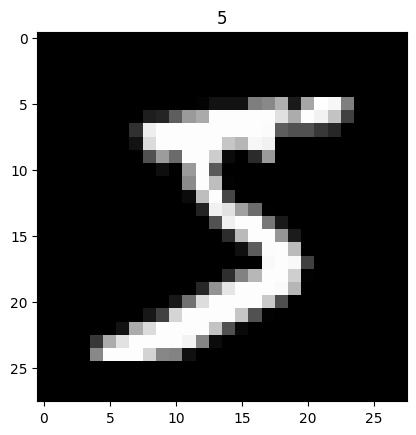

In [ ]:
plt.imshow(x_train[0], cmap='gray')
plt.title(y_train[0])
plt.show()

Normalize Data

CNN learns better with small values.

In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

Reshape Data

CNN requires:

(height, width, channels)

In [ ]:
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

Here:

28 = height
28 = width
1 = grayscale channel

Build CNN Model

In [ ]:
model = keras.Sequential([

    keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),

    keras.layers.Dense(64, activation='relu'),

    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Architecture

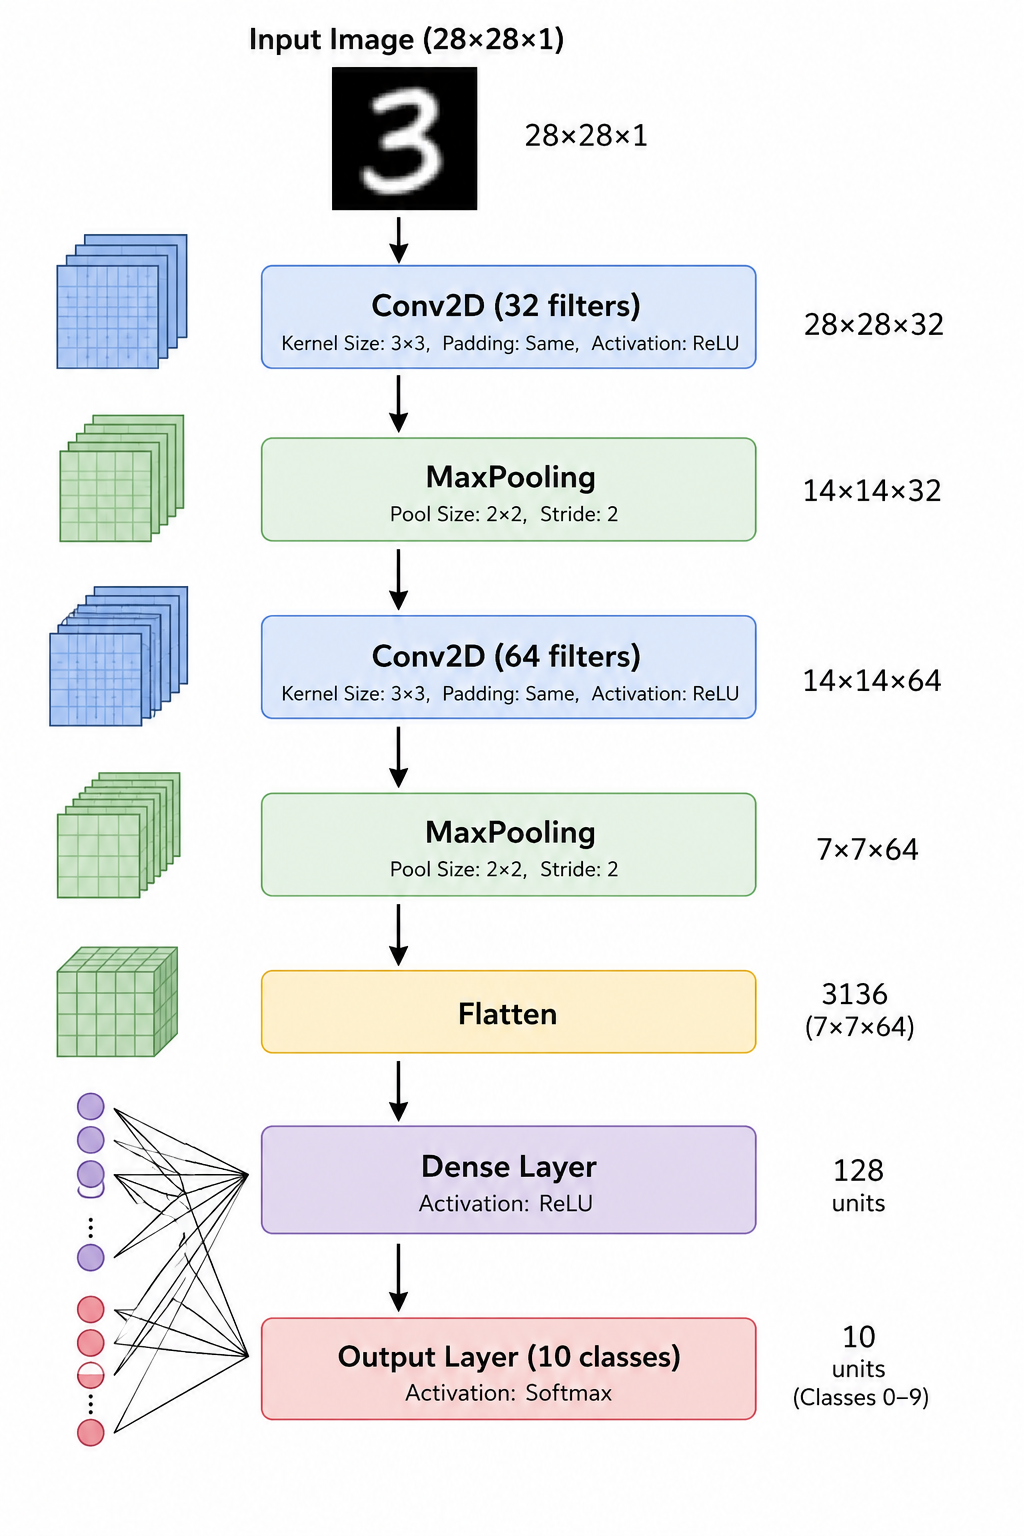

Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train Model

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9515 - loss: 0.1554 - val_accuracy: 0.9788 - val_loss: 0.0728
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9837 - loss: 0.0515 - val_accuracy: 0.9872 - val_loss: 0.0466
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9891 - loss: 0.0345 - val_accuracy: 0.9870 - val_loss: 0.0443
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9907 - loss: 0.0272 - val_accuracy: 0.9879 - val_loss: 0.0400
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9933 - loss: 0.0203 - val_accuracy: 0.9883 - val_loss: 0.0447


Evaluate Model

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9900 - loss: 0.0331
Accuracy: 0.9900000095367432


Prediction

In [ ]:
prediction = model.predict(x_test)

print("Predicted:", prediction[0].argmax())
print("Actual:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted: 7
Actual: 7


Display Prediction

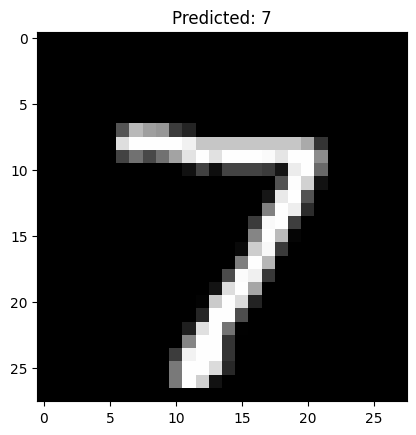

In [ ]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')

plt.title(
    f"Predicted: {prediction[0].argmax()}"
)

plt.show()

Important CNN Concepts
1. Conv2D
Conv2D(32,(3,3))
32 filters
Filter size = 3×3
Detects:
edges
curves
patterns
2. ReLU Activation
activation='relu'

Removes negative values.

Adds non-linearity.

3. MaxPooling
MaxPooling2D((2,2))

Reduces image size.

Makes training faster.

4. Flatten

Converts 2D feature maps into 1D vector.

5. Softmax
Dense(10, activation='softmax')

Converts outputs into probabilities.

In [ ]:
model.save("cnn_digit_model.h5")

In [ ]:
from tensorflow import keras

model = keras.models.load_model("cnn_digit_model.h5")

In [ ]:
prediction = model.predict(x_test)

print(prediction[0].argmax())

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
7


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from PIL import Image

from google.colab import files

# UPLOAD IMAGE

uploaded = files.upload()
=
# GET FILE NAME

filename = list(uploaded.keys())[0]

# LOAD MODEL

model = keras.models.load_model("cnn_digit_model.h5")

# OPEN IMAGE

img = Image.open(filename).convert("L")

# RESIZE IMAGE

img = img.resize((28,28))

# CONVERT TO ARRAY

img_array = np.array(img)

# INVERT COLORS

img_array = 255 - img_array

# NORMALIZE

img_array = img_array / 255.0

# SHOW IMAGE

plt.imshow(img_array, cmap='gray')
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

# RESHAPE FOR CNN

img_array = img_array.reshape(1,28,28,1)

# PREDICT

prediction = model.predict(img_array)

predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)

SyntaxError: invalid syntax (2036617677.py, line 12)